In [1]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split

In [2]:
features = pd.read_csv(
    "../data/processed/image_features.csv"
)

features.head()

,mean_brightness,contrast,edge_density,dark_pixel_ratio,defect_probability,cell_type
0,72.469667,17.068925,0.000000,0.122967,1.0,mono
1,84.836144,20.891564,0.000000,0.092678,1.0,mono
2,76.530200,16.200018,0.000000,0.099733,1.0,mono
3,90.565211,21.897937,0.000000,0.060467,0.0,mono
4,117.486189,38.802465,0.008111,0.084978,1.0,mono


In [3]:
print("Rows and columns:", features.shape)

Rows and columns: (2624, 6)


In [4]:
features["is_defective"] = (
  features["defect_probability"] >= 0.5
).astype(int)

In [5]:
features[
  ["defect_probability", "is_defective"]
].drop_duplicates().sort_values("defect_probability")

,defect_probability,is_defective
3,0.000000,0
57,0.333333,0
69,0.666667,1
0,1.000000,1


In [6]:
class_counts = features["is_defective"].value_counts()
class_percentages = (
    features["is_defective"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Counts:")
print(class_counts)

print("\nPercentages:")
print(class_percentages)

Counts:
is_defective
0    1803
1     821
Name: count, dtype: int64

Percentages:
is_defective
0    68.71
1    31.29
Name: proportion, dtype: float64


In [10]:
feature_names = [
  "mean_brightness",
  "contrast",
  "edge_density",
  "dark_pixel_ratio"
]

X = features[feature_names]
y = features["is_defective"]

In [11]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2624, 4)
y shape: (2624,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 2099
Testing examples: 525


In [14]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

In [15]:
dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.69,0.31]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['mean_brightness','contrast','edge_density','dark_pixel_ratio']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [16]:
dummy_predictions = dummy_model.predict(X_test)

In [17]:
dummy_accuracy = accuracy_score(
    y_test,
    dummy_predictions
)

dummy_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dummy_predictions
)

print("Dummy accuracy:", round(dummy_accuracy, 3))
print(
    "Dummy balanced accuracy:",
    round(dummy_balanced_accuracy, 3)
)

Dummy accuracy: 0.688
Dummy balanced accuracy: 0.5


## Logistic Regression Pipeline

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [21]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [22]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['mean_brightness','contrast','edge_density','dark_pixel_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [23]:
model_predictions = model.predict(X_test)

print("Number of predictions:", len(model_predictions))
print("First 10 predictions:", model_predictions[:10])

Number of predictions: 525
First 10 predictions: [1 0 0 0 0 0 1 0 1 0]


In [24]:
model_accuracy = accuracy_score(
    y_test,
    model_predictions
)

model_balanced_accuracy = balanced_accuracy_score(
    y_test,
    model_predictions
)

print(
    "Logistic regression accuracy:",
    round(model_accuracy, 3)
)

print(
    "Logistic regression balanced accuracy:",
    round(model_balanced_accuracy, 3)
)

print(
    "Dummy balanced accuracy:",
    round(dummy_balanced_accuracy, 3)
)

Logistic regression accuracy: 0.724
Logistic regression balanced accuracy: 0.708
Dummy balanced accuracy: 0.5


In [25]:
print(
    classification_report(
        y_test,
        model_predictions,
        target_names=[
            "Not defective",
            "Defective"
        ]
    )
)

               precision    recall  f1-score   support

Not defective       0.83      0.75      0.79       361
    Defective       0.55      0.66      0.60       164

     accuracy                           0.72       525
    macro avg       0.69      0.71      0.69       525
 weighted avg       0.74      0.72      0.73       525



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

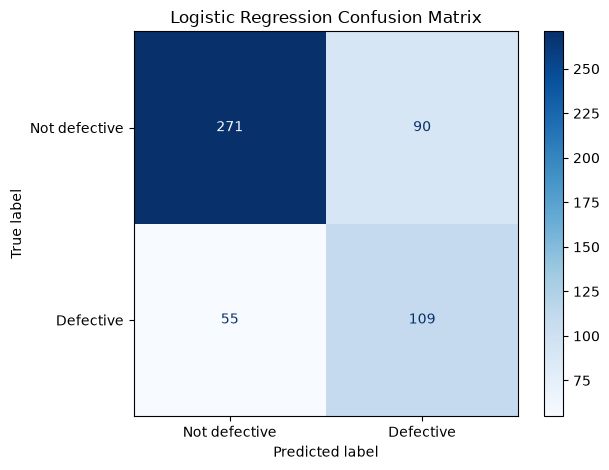

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions,
    display_labels=[
        "Not defective",
        "Defective"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Baseline-model findings

- The logistic-regression model achieved an accuracy of 72.4% and a balanced accuracy of 70.8%.
- This exceeded the dummy classifier's balanced accuracy of 50% which shows that the engineered image features contain useful information for defect classification.
- The model correctly detected 109 of 164 defective cells, giving the defective class a recall of 66%.
- It missed 55 defective cells and incorrectly flagged 90 nondefective cells.
- Defective precision was 55%, so slightly more than half of the model's defect predictions were correct.
- The baseline performs better than guessing, but its errors suggest that four summary features cannot capture all spatial patterns, cracks, and localized defects in the images.
- A model that uses the image pixels directly may be able to learn more detailed visual patterns.

In [29]:
coefficients = pd.Series(
    model.named_steps["classifier"].coef_[0],
    index=feature_names
).sort_values()

coefficients

mean_brightness    -0.914011
edge_density       -0.337089
contrast            0.694720
dark_pixel_ratio    0.768518
dtype: float64

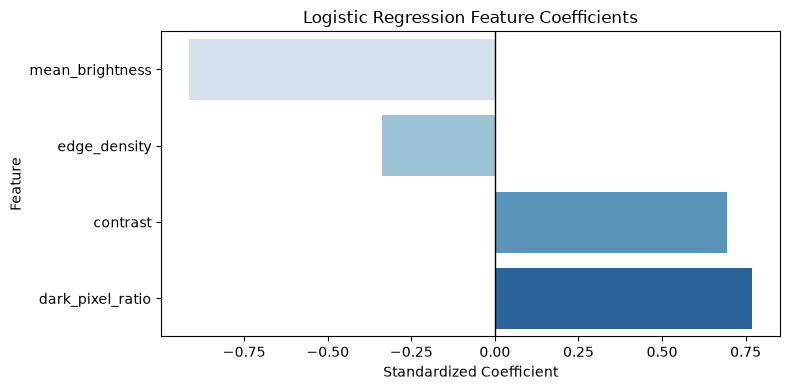

In [33]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=coefficients.values,
    y=coefficients.index,
    hue=coefficients.index,
    palette="Blues",
    legend=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../reports/figures/logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()